# **Custom Models and Training with TensorFlow**

TensorFlow offers many more features built on top of these core features: the most
important is of course tf.keras,1 but it also has data loading and preprocessing ops
(tf.data, tf.io, etc.), image processing ops (tf.image), signal processing ops
(tf.signal), and more (see Figure 12-1 for an overview of TensorFlow’s Python
API).

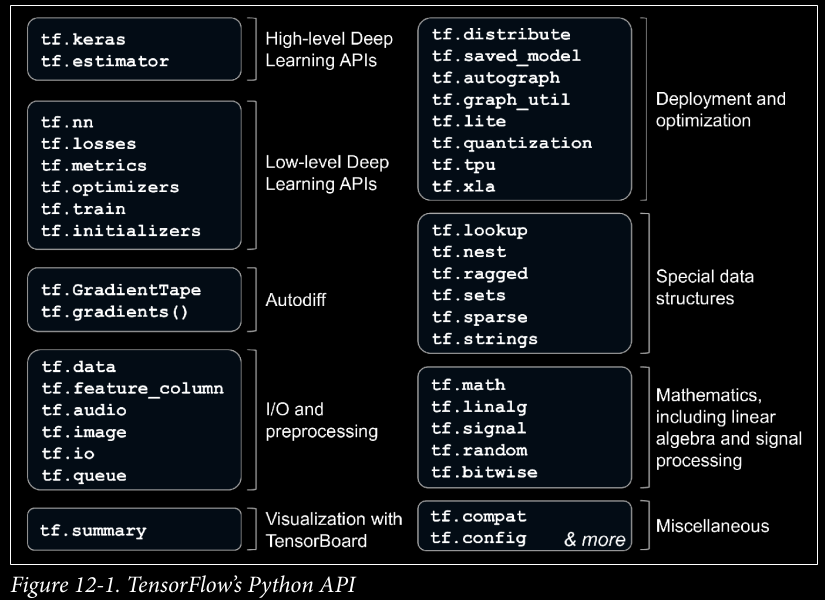

### **Tensors and Operations**

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

tf.constant([[1., 2., 3.], 
             [4., 5., 6.]])

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [7]:
tf.constant(2)

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [6]:
a=tf.constant(32)
print(a.dtype)

<dtype: 'int32'>


In [9]:
t = tf.constant([[1., 2., 3.], 
                 [4., 5., 6.]])

t[:, 1:]

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 3.],
       [5., 6.]], dtype=float32)>

In [17]:
t[..., 1, tf.newaxis]

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.],
       [5.]], dtype=float32)>

In [18]:
t + 10

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[11., 12., 13.],
       [14., 15., 16.]], dtype=float32)>

In [19]:
t

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [20]:
tf.square(t)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)>

In [21]:
t @ tf.transpose(t)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[14., 32.],
       [32., 77.]], dtype=float32)>

Density Estimation: KDE, Normalizing Flows ?

In [22]:
from tensorflow import keras
K = keras.backend
K.square(K.transpose(t)) + 10

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[11., 26.],
       [14., 35.],
       [19., 46.]], dtype=float32)>

In [23]:
a = np.array([2., 4., 5.])
tf.constant(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([2., 4., 5.])>

In [24]:
t.numpy()

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [25]:
tf.square(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 4., 16., 25.])>

In [26]:
np.square(t)

array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)

### **Type Conversions**

In [27]:
tf.constant(2.) + tf.constant(40)

InvalidArgumentError: cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a int32 tensor [Op:AddV2] name: 

InvalidArgumentError: cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a int32 tensor [Op:AddV2] name: 

In [28]:
tf.constant(2.) + tf.constant(40., dtype=tf.float64)

InvalidArgumentError: cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:AddV2] name: 

you can use tf.cast() when you really need to convert types:

In [29]:
t2 = tf.constant(40., dtype=tf.float64)
tf.constant(2.0) + tf.cast(t2, tf.float32)

<tf.Tensor: shape=(), dtype=float32, numpy=42.0>

### **Variables**

The tf.Tensor values we\u2019ve seen so far are immutable: you cannot modify them. This
means that we cannot use regular tensors to implement weights in a neural network,
since they need to be tweaked by backpropagation. Plus, other parameters may also
need to change over time

In [30]:
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])
v

<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [31]:
v.assign(2 * v)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2.,  4.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [32]:
v[0, 1].assign(42)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [34]:
v[:, 2].assign([0., 1.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  0.],
       [ 8., 10.,  1.]], dtype=float32)>

you will rarely have to create variables manually, since
Keras provides an add_weight() method

In [35]:
v.scatter_nd_update(indices=[[0, 0], [1, 2]], updates=[100., 200.])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[100.,  42.,   0.],
       [  8.,  10., 200.]], dtype=float32)>

## **Other Data Structures**

### **Sparse tensors (tf.SparseTensor)**

In [37]:
st = tf.sparse.SparseTensor(indices=[[0, 0], [1, 2]], values=[100., 200.], dense_shape=[2, 3])
st

SparseTensor(indices=tf.Tensor(
[[0 0]
 [1 2]], shape=(2, 2), dtype=int64), values=tf.Tensor([100. 200.], shape=(2,), dtype=float32), dense_shape=tf.Tensor([2 3], shape=(2,), dtype=int64))

In [38]:
dense_matrix = tf.sparse.to_dense(st)
print(dense_matrix)

tf.Tensor(
[[100.   0.   0.]
 [  0.   0. 200.]], shape=(2, 3), dtype=float32)


### **Tensor arrays (tf.TensorArray)**

Tensor arrays (tf.TensorArray)
Are lists of tensors. They have a fixed size by default but can optionally be made
dynamic. All tensors they contain must have the same shape and data type.

### **Ragged tensors (tf.RaggedTensor)**

Represent static lists of lists of tensors, where every tensor has the same shape
and data type. The tf.ragged package contains operations for ragged tensors.

In [ ]:
ragged_tensor = tf.ragged.constant([[1, 2], [3], [4, 5, 6]])


In [41]:
ragged_tensor

<tf.RaggedTensor [[1, 2], [3], [4, 5, 6]]>


### **Sets**

Are represented as regular tensors (or sparse tensors). For example, tf.con
stant([[1, 2], [3, 4]]) represents the two sets {1, 2} and {3, 4}. More gener‐
ally, each set is represented by a vector in the tensor’s last axis. You can
manipulate sets using operations from the tf.sets package.

In [43]:
sets_tensor = tf.constant([[1, 2], [3, 4]])
sets_tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[1, 2],
       [3, 4]], dtype=int32)>

# **Customizing Models and Training Algorithms**

## **Custom Loss Functions**


In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np


2026-07-27 01:02:35.157821: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-27 01:02:35.175725: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-27 01:02:35.180468: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
# def huber_loss(y_true, y_pred):
#     error = y_true - y_pred
#     is_small_error = tf.abs(error) < 1
#     squared_loss = tf.square(error) / 2
#     linear_loss = tf.abs(error) - 0.5
#     return tf.where(is_small_error, squared_loss, linear_loss)

import tensorflow as tf

# delta == 1
@tf.function
def huber_fn(y_true, y_pred):
    error = y_true - y_pred
    
    is_small_error = tf.abs(error) < 1 
    
    squared_loss = tf.square(error) / 2
    linear_loss = tf.abs(error) - 0.5
    
    return tf.where(is_small_error, squared_loss, linear_loss)


@tf.function
def mse_fn(y_true, y_pred):
    """
    Mean Squared Error
    """
    error = y_true - y_pred
    
    return tf.reduce_mean(tf.square(error))


@tf.function
def mae_fn(y_true, y_pred):
    """
    Mean Absolute Error
    """
    error = y_true - y_pred
    
    return tf.reduce_mean(tf.abs(error))

In [12]:
y_true = tf.constant([[1.0, 2.0, 3.0],
                      [4.0, 5.0, 6.0]])

y_pred = tf.constant([[1.5, 1.0, 5.0],
                      [3.0, 5.5, 8.0]])

huber_loss = huber_fn(y_true, y_pred)
mse_loss = mse_fn(y_true, y_pred)
mae_loss = mae_fn(y_true, y_pred)


print("Huber Loss: ", huber_loss)
print("MSE Loss: ", mse_loss)
print("MAE Loss: ", mae_loss)


Huber Loss:  tf.Tensor(
[[0.125 0.5   1.5  ]
 [0.5   0.125 1.5  ]], shape=(2, 3), dtype=float32)
MSE Loss:  tf.Tensor(1.75, shape=(), dtype=float32)
MAE Loss:  tf.Tensor(1.1666666, shape=(), dtype=float32)


### **Saving and Loading Models That Contain Custom Components**

In [ ]:
model = keras.models.load_model(
    "my_model_with_a_custom_loss.h5",
    custom_objects={"huber_fn": huber_fn}
)

With the current implementation, any error between –1 and 1 is considered “small.”
But what if you want a different threshold? One solution is to create a function that
creates a configured loss function:

In [ ]:

def create_huber(threshold=1.0):
    def huber_fn(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < threshold
        squared_loss = tf.square(error) / 2
        linear_loss = threshold * tf.abs(error) - threshold**2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)
    return huber_fn

model.compile(loss=create_huber(2.0), optimizer="nadam")

Unfortunately, when you save the model, the threshold will not be saved. This means
that you will have to specify the threshold value when loading the model (note that
the name to use is "huber_fn", which is the name of the function you gave Keras, not
the name of the function that created it):

In [ ]:
model = keras.models.load_model(
    "my_model_with_a_custom_loss_threshold_2.h5",
    custom_objects={"huber_fn": create_huber(2.0)}
)

In [13]:
import keras
class Huber_fun(keras.losses.Loss):
    def __init__(self, threshold=1.0, **kwargs):
        self.threshold = threshold
        super().__init__(**kwargs)
    def call(self, y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < self.threshold
        squared_loss = tf.square(error) / 2
        linear_loss = self.threshold * tf.abs(error) - self.threshold**2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}  
    

In [ ]:
# When you save the model, the threshold will be saved along with it; and when you
# load the model, you just need to map the class name to the class itself:

model = keras.models.load_model("my_model_with_a_custom_loss_class.h5",
custom_objects={"HuberLoss": Huber_fun})

### **Custom Activation Functions, Initializers, Regularizers, and Constraints**

In [ ]:
def my_softplus(z): # return value is just tf.nn.softplus(z)
    return tf.math.log(tf.exp(z) + 1.0)

def my_glorot_initializer(shape, dtype=tf.float32):
    stddev = tf.sqrt(2. / (shape[0] + shape[1]))
    return tf.random.normal(shape, stddev=stddev, dtype=dtype)

def my_l1_regularizer(weights):
    return tf.reduce_sum(tf.abs(0.01 * weights))

def my_positive_weights(weights): # return value is just tf.nn.relu(weights)
    return tf.where(weights < 0., tf.zeros_like(weights), weights)

**These Custom Function can be used:**

In [ ]:
layer = keras.layers.Dense(
    30, activation=my_softplus,
    kernel_initializer=my_glorot_initializer,
    kernel_regularizer=my_l1_regularizer,
    kernel_constraint=my_positive_weights
)

if the func has params the i can use sub classes:

In [ ]:
class MyL1Regularizer(keras.regularizers.Regularizer):
    def __init__(self, factor):
        self.factor = factor
    def __call__(self, weights):
        return tf.reduce_sum(tf.abs(self.factor * weights))
    def get_config(self):
        return {"factor": self.factor}

In [ ]:
model = keras.models.load_model("my_model_with_a_custom_loss_class.h5",
custom_objects={"HuberLoss": Huber_fun})

keras.models.save_model("MyModelwithL1regularizer", custom_objects={"MyL1Regularizer", MyL1Regularizer})


## **Custom Metrics**

In [ ]:
model.compile(loss="mse", optimizer="nadam", metrics=[create_huber(2.0)])

In [19]:
precision = keras.metrics.Precision()
precision([0, 1, 1, 1, 0, 1, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1])
# <tf.Tensor: id=581729, shape=(), dtype=float32, numpy=0.8>
precision([0, 1, 0, 0, 1, 0, 1, 1], [1, 0, 1, 1, 0, 0, 0, 0])
# <tf.Tensor: id=581780, shape=(), dtype=float32, numpy=0.5>

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In [16]:
precision.result()
# <tf.Tensor: id=581794, shape=(), dtype=float32, numpy=0.5>
precision.variables
# [<tf.Variable 'true_positives:0' [...] numpy=array([4.], dtype=float32)>,
# <tf.Variable 'false_positives:0' [...] numpy=array([4.], dtype=float32)>]
# precision.reset_states() # both variables get reset to 0.0

[<Variable path=precision/true_positives, shape=(1,), dtype=float32, value=[4.]>,
 <Variable path=precision/false_positives, shape=(1,), dtype=float32, value=[4.]>]

## **Streaming Metric**

In [20]:
def create_huber(threshold=1.0):
    def huber_fn(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < threshold
        squared_loss = tf.square(error) / 2
        linear_loss = tf.abs(error) - 0.5
        return tf.where(is_small_error, squared_loss, linear_loss)
    return huber_fn

In [21]:
class HuberMetric(keras.metrics.Metric):
    def __init__(self, threshold=1.0, **kwargs):
        super().__init__(**kwargs) # handles base args (e.g., dtype)
        self.threshold = threshold
        self.huber_fn = create_huber(threshold)
        self.total = self.add_weight("total", initializer="zeros")
        self.count = self.add_weight("count", initializer="zeros")
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        metric = self.huber_fn(y_true, y_pred)
        self.total.assign_add(tf.reduce_sum(metric))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))
    def result(self):
        return self.total / self.count
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

## **Custom Layers**

In [ ]:
exponential_layer = keras.layers.Lambda(lambda x: tf.exp(x))

In [ ]:
class MyDense(keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)
    def build(self, batch_input_shape):
        self.kernel = self.add_weight(
            name="kernel", shape=[batch_input_shape[-1], self.units],
            initializer="glorot_normal")
        self.bias = self.add_weight(
            name="bias", shape=[self.units], initializer="zeros")
        super().build(batch_input_shape) # must be at the end
    def call(self, X):
        return self.activation(X @ self.kernel + self.bias)
    def compute_output_shape(self, batch_input_shape):
        return tf.TensorShape(batch_input_shape.as_list()[:-1] + [self.units])
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "units": self.units, 
                "activation": keras.activations.serialize(self.activation)}

In [ ]:
class MyMultiLayer(keras.layers.Layer):
    def call(self, X):
        X1, X2 = X
        return [X1 + X2, X1 * X2, X1 / X2]
    def compute_output_shape(self, batch_input_shape):
        b1, b2 = batch_input_shape
        return [b1, b1, b1] # should probably handle broadcasting rules
    


## **Custom Models**

In [23]:

inputs = keras.layers.Input(shape=(28, 28))

x = keras.layers.Flatten()(inputs)
x = keras.layers.Dense(256, activation="relu", kernel_initializer="glorot_uniform" )(x)

shortcut1 = x

x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dense(256)(x)
x = keras.layers.Add()([x, shortcut1])
x = keras.layers.Activation("relu")(x)

shortcut2 = x

x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dense(256)(x)
x = keras.layers.Add()([x, shortcut2])
x = keras.layers.Activation("relu")(x)

outputs = keras.layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense_2[0][0],    │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense_4[0][0],    │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │      2,570 │ activation_1[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 466,698 (1.78 MB)

 Trainable params: 466,698 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
keras.backend.clear_session()

In [14]:
class ResidualBlock(keras.layers.Layer):

    def __init__(self, n_layers, n_neurons, **kwargs):
        super().__init__(**kwargs)

        self.hidden = [
            keras.layers.Dense(
                n_neurons,
                activation="elu",
                kernel_initializer="he_normal"
            )
            for _ in range(n_layers)
        ]

    def call(self, inputs):
        Z = inputs

        for layer in self.hidden:
            Z = layer(Z)

        return inputs + Z

In [15]:
class ResidualRegressor(keras.Model):

    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)

        self.hidden1 = keras.layers.Dense(
            30,
            activation="elu",
            kernel_initializer="he_normal"
        )

        self.block1 = ResidualBlock(2, 30)
        self.block2 = ResidualBlock(2, 30)

        self.out = keras.layers.Dense(output_dim)


    def call(self, inputs):

        Z = self.hidden1(inputs)

        for _ in range(4):
            Z = self.block1(Z)

        Z = self.block2(Z)

        return self.out(Z)

In [16]:
model1 = ResidualRegressor(output_dim=1)

model1.build((None,10))

# Important: force tracing
model1(tf.zeros((1,10)))

model1.summary()

/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'residual_regressor', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "residual_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 30)                │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block (ResidualBlock)  │ ?                      │         1,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_1                │ ?                      │         1,860 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 1)                 │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

# **Losses and Metrics Based on Model Internals**

In [ ]:
class ReconstructingRegressor(keras.Model):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden = [keras.layers.Dense(30, activation="selu",kernel_initializer="lecun_normal")for _ in range(5)]
        self.out = keras.layers.Dense(output_dim)
    
    def build(self, batch_input_shape):
        n_inputs = batch_input_shape[-1]
        self.reconstruct = keras.layers.Dense(n_inputs)
        super().build(batch_input_shape)
        
    def call(self, inputs):
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        reconstruction = self.reconstruct(Z)
        recon_loss = tf.reduce_mean(tf.square(reconstruction - inputs))
        self.add_loss(0.05 * recon_loss)
        return self.out(Z)

## **Computing Gradients Using Autodiff**